In [1]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv('sales_data.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


Saving sales_data.csv to sales_data.csv


In [2]:
#print(df)
subset=df[['Product','Sales']]
print(subset)

     Product  Sales
0     Webcam   2011
1     Laptop   2428
2    Monitor   4163
3     Laptop   1932
4     Webcam   3821
5     Laptop   3645
6    Monitor   2562
7   Keyboard   4267
8   Keyboard   4503
9     Webcam   4652
10     Mouse   1433
11    Webcam    776
12    Laptop   3734
13     Mouse   3869
14    Laptop   1512
15    Laptop   2482
16    Webcam   4019
17   Monitor   3217
18    Webcam   2142
19    Webcam   2349
20  Keyboard   3502
21     Mouse   3824
22  Keyboard   3465
23    Laptop   4229
24    Webcam    680
25    Laptop   3585
26    Webcam   1959
27   Monitor   4764
28   Monitor   2266
29    Webcam   1873
30  Keyboard   3627
31  Keyboard   4843
32  Keyboard   2197
33     Mouse   3022
34  Keyboard   4418
35     Mouse   4962
36     Mouse   2924
37    Laptop   2861
38  Keyboard   3582
39    Laptop    951
40    Webcam   3244
41   Monitor   4024
42   Monitor   2110
43     Mouse   1902
44  Keyboard   1110
45   Monitor   2882
46   Monitor   4357
47   Monitor   1490
48    Laptop    903


In [3]:
# print that in which rows have nagpur

import pandas as pd
df=pd.read_csv('sales_data.csv')
print(df.columns)

# Filter rows where region is 'Nagpur'
nagpur_rows = df[df['Region'] == 'Nagpur']

# Print the result
print(nagpur_rows)

Index(['Order_ID', 'Product', 'Region', 'Sales', 'Quantity', 'Profit'], dtype='object')
    Order_ID   Product  Region  Sales  Quantity  Profit
5       1006    Laptop  Nagpur   3645         2     674
6       1007   Monitor  Nagpur   2562         2     584
8       1009  Keyboard  Nagpur   4503         4     488
9       1010    Webcam  Nagpur   4652         1    -103
11      1012    Webcam  Nagpur    776         2     541
25      1026    Laptop  Nagpur   3585         3     413
26      1027    Webcam  Nagpur   1959         5    -167
30      1031  Keyboard  Nagpur   3627         7     -39
36      1037     Mouse  Nagpur   2924         5     374
37      1038    Laptop  Nagpur   2861         1      40
39      1040    Laptop  Nagpur    951         1       0
40      1041    Webcam  Nagpur   3244         8      84
41      1042   Monitor  Nagpur   4024         4     219
44      1045  Keyboard  Nagpur   1110         9     -12


In [4]:
#sales sorting
df.sort_values(by= 'Sales', ascending= False)

,Order_ID,Product,Region,Sales,Quantity,Profit
35,1036,Mouse,West,4962,4,272
31,1032,Keyboard,South,4843,6,289
27,1028,Monitor,South,4764,3,124
9,1010,Webcam,Nagpur,4652,1,-103
8,1009,Keyboard,Nagpur,4503,4,488
34,1035,Keyboard,South,4418,3,425
46,1047,Monitor,West,4357,1,-186
7,1008,Keyboard,East,4267,3,305
23,1024,Laptop,North,4229,3,316
2,1003,Monitor,North,4163,6,762


In [5]:
##total Sale

total_sales = df['Sales'].sum()
min_sales = df['Sales'].min()

total_profit = df['Profit'].sum()
min_profit = df['Profit'].min()

print("Total Sales:", total_sales)
print("Minimum Sales:", min_sales)
print("Total Profit:", total_profit)
print("Minimum Profit:", min_profit)

Total Sales: 146658
Minimum Sales: 680
Total Profit: 15847
Minimum Profit: -186


In [6]:
df.groupby("Region")['Sales'].sum().reset_index()

,Region,Sales
0,East,22438
1,Nagpur,40423
2,North,18075
3,South,33842
4,West,31880


In [7]:
##find out the product wise avg.  price and total sum 1. sale - avg, 2. quantity sum
Sales = df.groupby('Product').agg({
    'Sales': 'mean',      # average sale
    'Quantity': 'sum'     # total quantity
}).reset_index()          # make grouped data a normal DataFrame

# Print the grouped summary
print(df)

    Order_ID   Product  Region  Sales  Quantity  Profit
0       1001    Webcam    West   2011         3     486
1       1002    Laptop    West   2428         2     143
2       1003   Monitor   North   4163         6     762
3       1004    Laptop   North   1932         9      92
4       1005    Webcam   South   3821         1     842
5       1006    Laptop  Nagpur   3645         2     674
6       1007   Monitor  Nagpur   2562         2     584
7       1008  Keyboard    East   4267         3     305
8       1009  Keyboard  Nagpur   4503         4     488
9       1010    Webcam  Nagpur   4652         1    -103
10      1011     Mouse    East   1433         6     400
11      1012    Webcam  Nagpur    776         2     541
12      1013    Laptop    West   3734         5     267
13      1014     Mouse    West   3869         1     -94
14      1015    Laptop   North   1512         5     691
15      1016    Laptop    East   2482         8      80
16      1017    Webcam    West   4019         3 

In [8]:
# check missing values
print(df.isnull().sum())

# check duplicates
print(df.duplicated().sum())

# remove duplicates if any
df = df.drop_duplicates()

Order_ID    0
Product     0
Region      0
Sales       0
Quantity    0
Profit      0
dtype: int64
0


In [9]:
df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

,Sales
Product,
Keyboard,37099
Monitor,31835
Laptop,28262
Webcam,27526
Mouse,21936


In [10]:
df.groupby('Product')['Profit'].sum().sort_values(ascending=False)

,Profit
Product,
Webcam,5139
Laptop,3225
Monitor,2960
Keyboard,2838
Mouse,1685


In [11]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

,Sales
Region,
Nagpur,40423
South,33842
West,31880
East,22438
North,18075


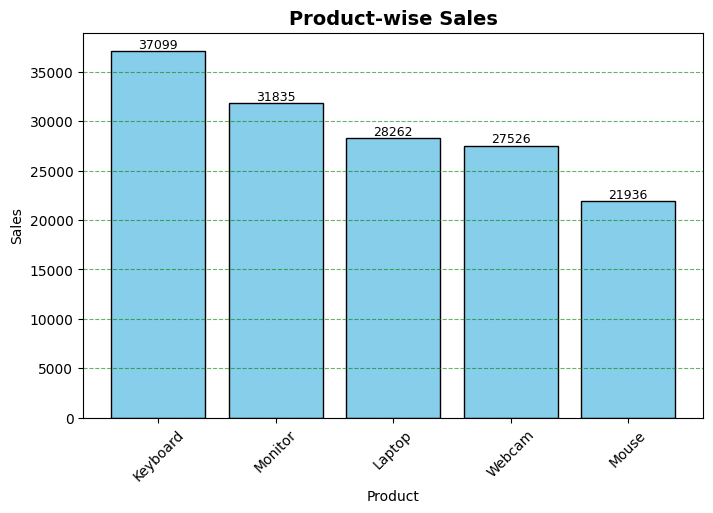

In [13]:
import matplotlib.pyplot as plt

#Graph 1:  Product Wise Sales (Bar Chart)

product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(product_sales.index, product_sales.values, color='Skyblue', edgecolor='black')

plt.title("Product-wise Sales", fontsize=14, fontweight='bold')
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', color='green', alpha=0.6)

# value labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, int(y),
             ha='center', va='bottom', fontsize=9)

plt.show()

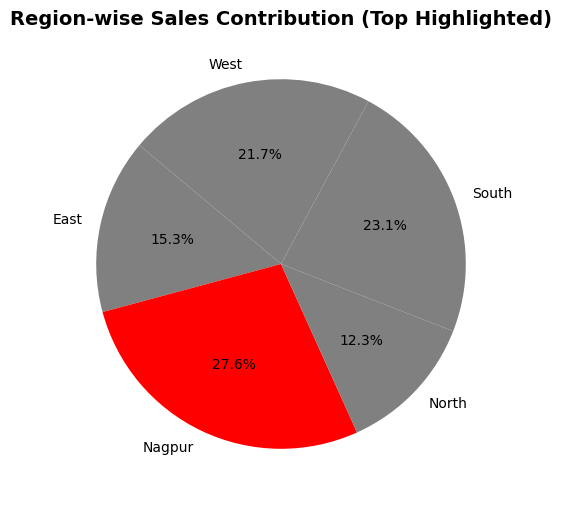

In [14]:
# Graph2: Region Contribution (Pie Chart)
region_sales = df.groupby('Region')['Sales'].sum()

# Default colors
colors = ['gray'] * len(region_sales)

# Highlight max region
max_region = region_sales.idxmax()
colors[list(region_sales.index).index(max_region)] = 'red'

plt.figure(figsize=(6,6))

plt.pie(region_sales.values,
        labels=region_sales.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140)

plt.title("Region-wise Sales Contribution (Top Highlighted)", fontsize=14, fontweight='bold')

plt.show()

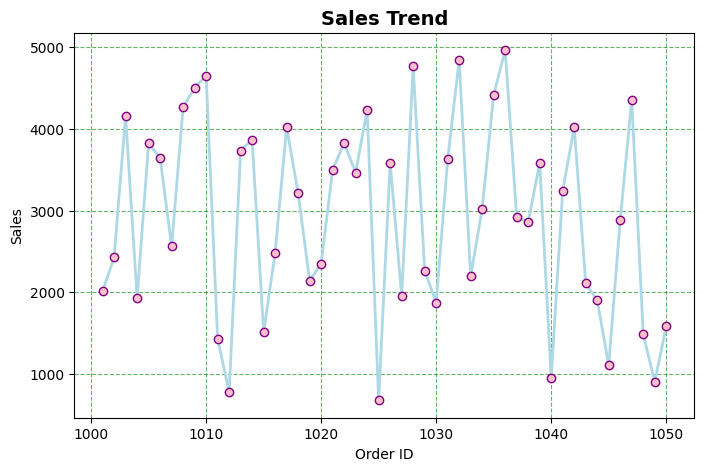

In [15]:
#Graph 3 : Sales Trend (Line Chart – fake time trend)

df_sorted = df.sort_values('Order_ID')

plt.figure(figsize=(8,5))
plt.plot(df_sorted['Order_ID'], df_sorted['Sales'],color='lightblue',
         marker='o',markeredgecolor='purple',markerfacecolor='pink', linewidth=2)

plt.title("Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Order ID")
plt.ylabel("Sales")

plt.grid(True, linestyle='--', color='green', alpha=0.6)
plt.show()

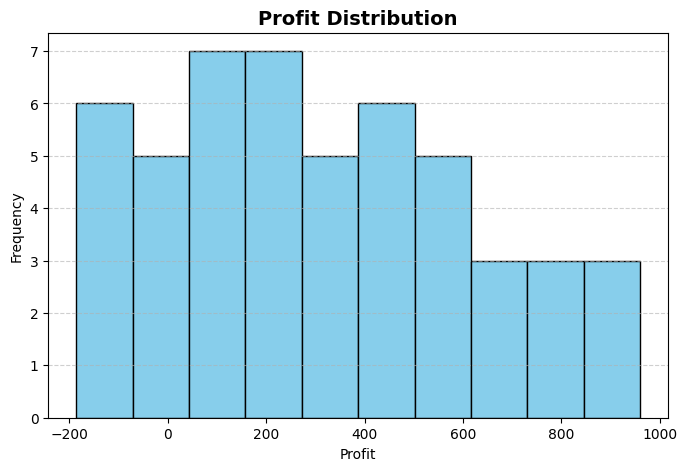

In [16]:
#Graph 4:- Profit Distribution (Histogram)

plt.figure(figsize=(8,5))
plt.hist(df['Profit'], bins=10, edgecolor='black',color='Skyblue')

plt.title("Profit Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

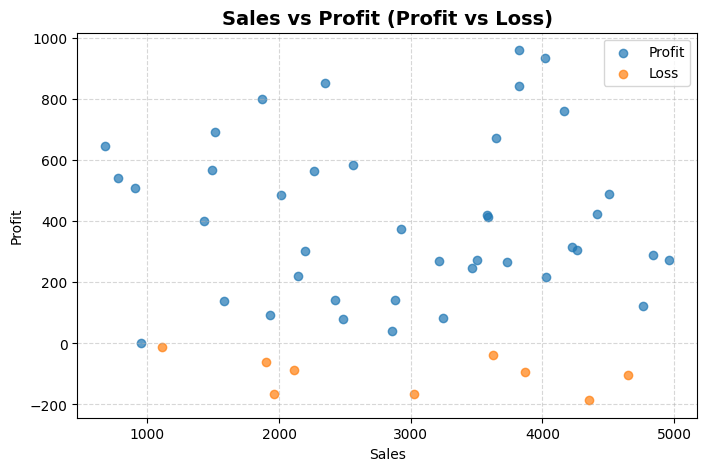

In [17]:
# Graph 5 :- Sales vs Profit (Scatter Plot)

plt.figure(figsize=(8,5))

# Separate profit and loss
profit_data = df[df['Profit'] >= 0]
loss_data = df[df['Profit'] < 0]

# Plot both
plt.scatter(profit_data['Sales'], profit_data['Profit'], label='Profit', alpha=0.7)
plt.scatter(loss_data['Sales'], loss_data['Profit'], label='Loss', alpha=0.7)

plt.title("Sales vs Profit (Profit vs Loss)", fontsize=14, fontweight='bold')
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()